In [2]:
%matplotlib inline

In [3]:
# ── Standard library imports ──────────────────────────────────────────────────
import sys, os, warnings
warnings.filterwarnings('ignore')       # hide noisy warnings while we learn

# Tell Python where our src/ folder is
sys.path.insert(0, os.path.join('..', 'src'))

# ── Data science libraries ─────────────────────────────────────────────────────
import numpy  as np          # fast math arrays
import pandas as pd          # tables (DataFrames)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ── Our custom indicators module ───────────────────────────────────────────────
from indicators import (
    simple_moving_average,
    exponential_moving_average,
    relative_strength_index,
    macd,
    bollinger_bands,
    daily_returns,
    cumulative_returns,
    rolling_volatility,
    add_all_indicators,        # adds ALL of the above in one call
)



In [4]:
# ── Chart styling ──────────────────────────────────────────────────────────────
# We use a dark theme so indicators are easier to read
PALETTE = '#1a1a2e #16213e #0f3460 #e94560 #533483 #2ecc71 #f39c12'.split()
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  'white',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       'white',
    'grid.color':       '#2a2a3e',
    'grid.linewidth':   0.6,
})

STOCKS   = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
DATA_DIR = '../data/stock_price'
print('✓ Stocks to analyse:', STOCKS)


✓ Stocks to analyse: ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']


In [5]:

dfs = {}   # empty dictionary to fill

for stock in STOCKS:
    filepath = f'{DATA_DIR}/{stock}.csv'
    
    df = pd.read_csv(
        filepath,
        parse_dates=['Date'],   # tell pandas 'Date' is a date, not text
    )
    df = df.set_index('Date')   # use Date as the row label (index)
    df = df.sort_index()        # make sure dates go oldest → newest
    
    dfs[stock] = df             # store in our dictionary
    print(f'  {stock}: {len(df):,} trading days  |  {df.index.min().date()} → {df.index.max().date()}')

print('\n✓ All stocks loaded!')


  AAPL: 3,774 trading days  |  2009-01-02 → 2023-12-29
  AMZN: 3,774 trading days  |  2009-01-02 → 2023-12-29
  GOOG: 3,774 trading days  |  2009-01-02 → 2023-12-29
  META: 2,923 trading days  |  2012-05-18 → 2023-12-29
  NVDA: 3,774 trading days  |  2009-01-02 → 2023-12-29

✓ All stocks loaded!


In [6]:
# Preview one stock to understand the raw data
print('Sample of AAPL data (first 5 rows):')
dfs['AAPL'].head()

Sample of AAPL data (first 5 rows):


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [7]:
# Basic statistics for AAPL close price
print('AAPL Close Price Statistics:')
dfs['AAPL']['Close'].describe().round(2)

AAPL Close Price Statistics:


count    3774.00
mean       53.84
std        55.06
min         2.35
25%        15.05
50%        26.98
75%        74.66
max       196.26
Name: Close, dtype: float64

In [8]:
# Add indicators to every stock
# This loop runs the same code for each of our 7 stocks

for stock in STOCKS:
    dfs[stock] = add_all_indicators(dfs[stock])
    print(f'  {stock}: now has {dfs[stock].shape[1]} columns')

print('\n✓ Indicators added!')
print('\nNew columns available:')
indicator_cols = [c for c in dfs['AAPL'].columns if c not in ['Open','High','Low','Close','Volume','Stock']]
for col in indicator_cols:
    print(f'  • {col}')
    

  AAPL: now has 20 columns
  AMZN: now has 20 columns
  GOOG: now has 20 columns
  META: now has 20 columns
  NVDA: now has 20 columns

✓ Indicators added!

New columns available:
  • sma_20
  • sma_50
  • ema_20
  • ema_50
  • rsi_14
  • macd
  • macd_signal
  • macd_hist
  • bb_middle
  • bb_upper
  • bb_lower
  • bb_bandwidth
  • daily_return
  • cumulative_return
  • volatility_30d


In [9]:
# Check the enriched AAPL data
print('AAPL with all indicators (last 5 rows):')
dfs['AAPL'][['Close','sma_20','ema_20','rsi_14','macd','daily_return']].tail().round(2)


AAPL with all indicators (last 5 rows):


,Close,sma_20,ema_20,rsi_14,macd,daily_return
Date,,,,,,
2023-12-22,191.79,191.86,191.51,54.67,2.63,-0.01
2023-12-26,191.24,192.02,191.48,53.09,2.30,-0.00
2023-12-27,191.34,192.15,191.47,53.35,2.03,0.00
2023-12-28,191.77,192.36,191.50,54.54,1.82,0.00
2023-12-29,190.73,192.49,191.43,51.12,1.56,-0.01


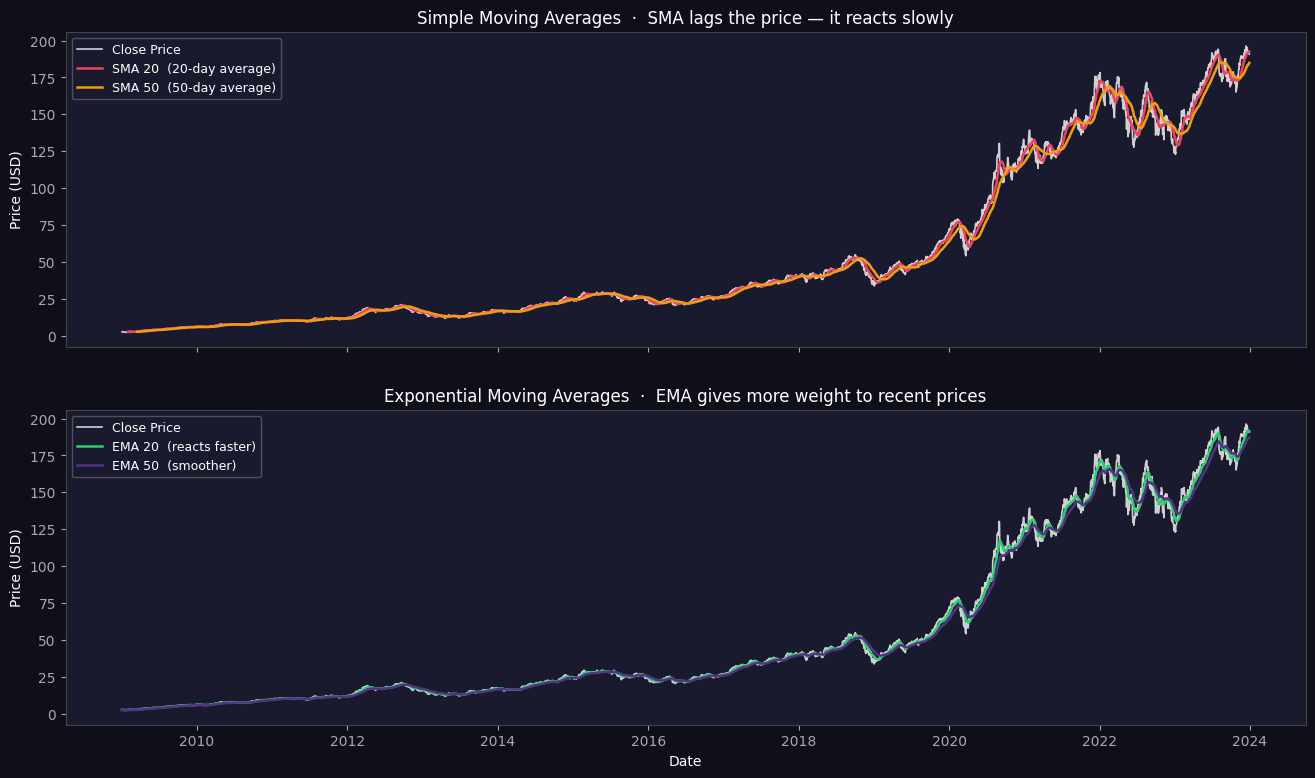

Key insight: Notice how EMA tracks price changes more tightly than SMA.
SMA is better for identifying long-term trends; EMA for shorter-term signals.


In [10]:
df = dfs['AAPL']

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# ── Top panel: Simple Moving Averages ─────────────────────────────────────────
ax = axes[0]
ax.plot(df.index, df['Close'],  color='white',   lw=1.2, alpha=0.8, label='Close Price')
ax.plot(df.index, df['sma_20'], color='#e94560', lw=1.8, label='SMA 20  (20-day average)')
ax.plot(df.index, df['sma_50'], color='#f39c12', lw=1.8, label='SMA 50  (50-day average)')
ax.set_ylabel('Price (USD)')
ax.set_title('Simple Moving Averages  ·  SMA lags the price — it reacts slowly')
ax.legend(framealpha=0.3, fontsize=9)

# ── Bottom panel: Exponential Moving Averages ──────────────────────────────────
ax = axes[1]
ax.plot(df.index, df['Close'],  color='white',   lw=1.2, alpha=0.8, label='Close Price')
ax.plot(df.index, df['ema_20'], color='#2ecc71', lw=1.8, label='EMA 20  (reacts faster)')
ax.plot(df.index, df['ema_50'], color='#533483', lw=1.8, label='EMA 50  (smoother)')
ax.set_ylabel('Price (USD)'); ax.set_xlabel('Date')
ax.set_title('Exponential Moving Averages  ·  EMA gives more weight to recent prices')
ax.legend(framealpha=0.3, fontsize=9)

plt.show()
print('Key insight: Notice how EMA tracks price changes more tightly than SMA.')
print('SMA is better for identifying long-term trends; EMA for shorter-term signals.')


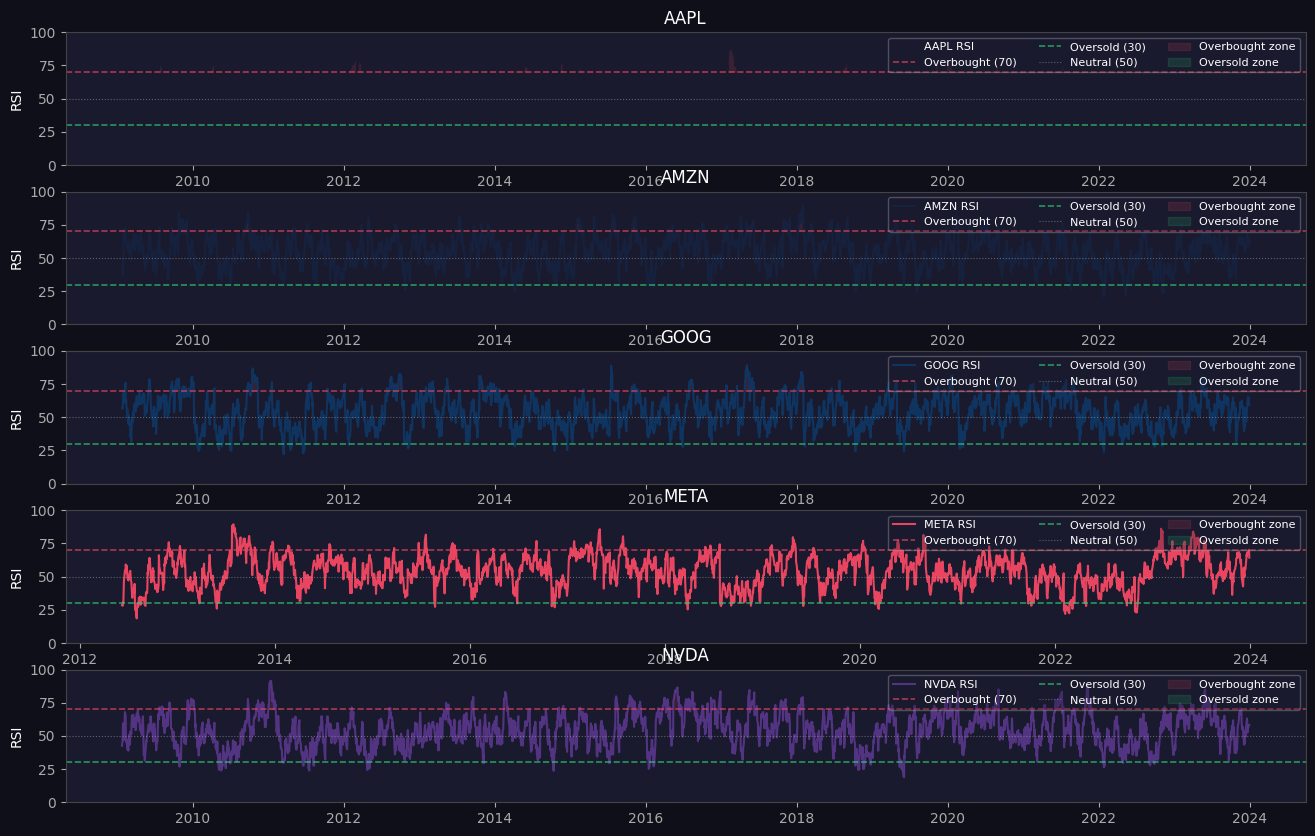

In [11]:
picks = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']

fig, axes = plt.subplots(5, 1, figsize=(16, 10))

for i, stock in enumerate(picks):
    df = dfs[stock]
    ax = axes[i]
    
    # Plot RSI line
    ax.plot(df.index, df['rsi_14'], color=PALETTE[i], lw=1.5, label=f'{stock} RSI')
    
    # Draw the overbought / oversold threshold lines
    ax.axhline(70, color='#e94560', lw=1.2, ls='--', alpha=0.7, label='Overbought (70)')
    ax.axhline(30, color='#2ecc71', lw=1.2, ls='--', alpha=0.7, label='Oversold (30)')
    ax.axhline(50, color='#aaa',    lw=0.8, ls=':',  alpha=0.5, label='Neutral (50)')
    
    # Shade the danger zones
    ax.fill_between(df.index, df['rsi_14'], 70, where=df['rsi_14'] >= 70,
                    color='#e94560', alpha=0.15, label='Overbought zone')
    ax.fill_between(df.index, df['rsi_14'], 30, where=df['rsi_14'] <= 30,
                    color='#2ecc71', alpha=0.15, label='Oversold zone')
    
    ax.set_ylim(0, 100)
    ax.set_ylabel('RSI')
    ax.set_title(stock)
    ax.legend(framealpha=0.3, fontsize=8, loc='upper right', ncol=3)


plt.show()

# print('Key insight: TSLA tends to spend more time in extreme zones (>70 or <30),')
# print('reflecting its history of sharp rallies and steep sell-offs.')

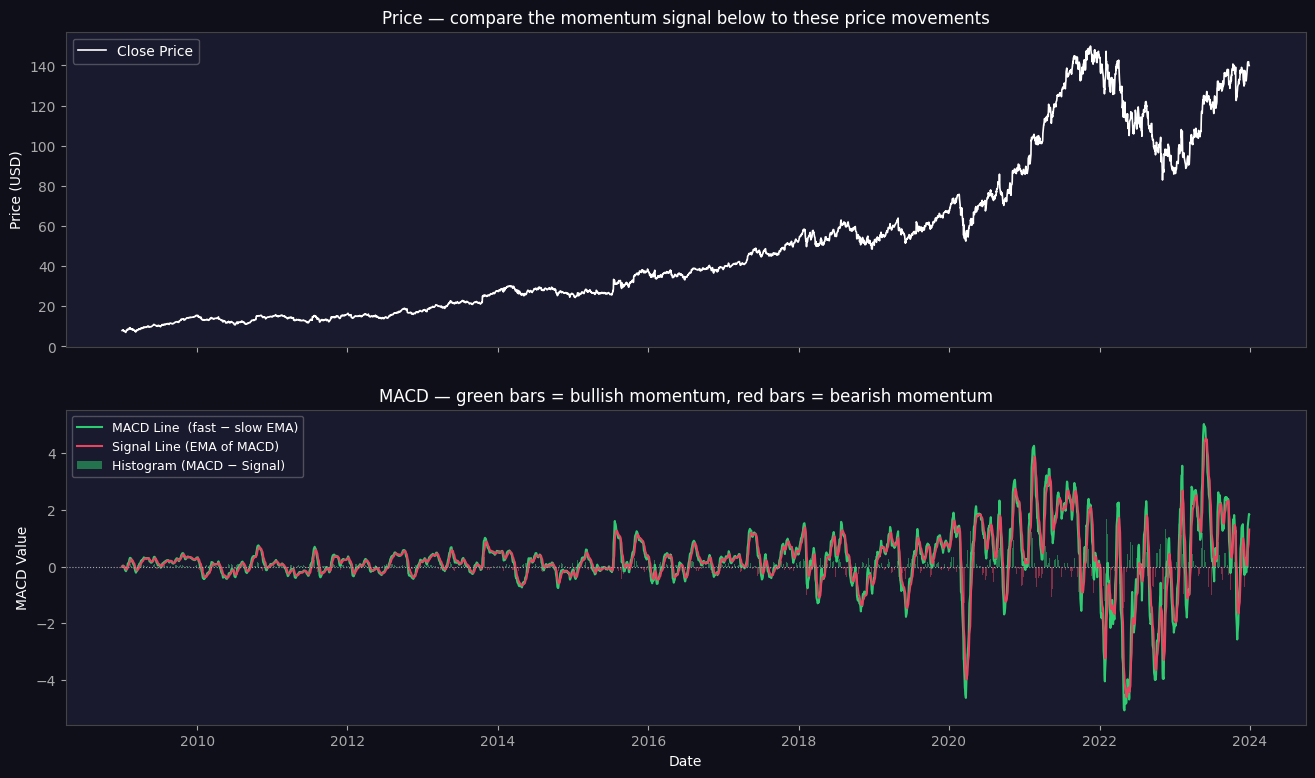

Key insight: Look for moments when the MACD line (green) crosses the Signal line (red).
A cross upward often precedes a price rally; a cross downward can precede a decline.


In [ ]:
df = dfs['GOOG']

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# ── Top: price for context ─────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df.index, df['Close'], color='white', lw=1.2, label='Close Price')
ax.set_ylabel('Price (USD)')
ax.set_title('Price — compare the momentum signal below to these price movements')
ax.legend(framealpha=0.3)

# ── Bottom: MACD ───────────────────────────────────────────────────────────────
ax = axes[1]

# Draw MACD and Signal lines
ax.plot(df.index, df['macd'],        color='#2ecc71', lw=1.5, label='MACD Line  (fast − slow EMA)')
ax.plot(df.index, df['macd_signal'], color='#e94560', lw=1.5, label='Signal Line (EMA of MACD)')

# Draw histogram bars — colour green if positive, red if negative
hist   = df['macd_hist']
colors = ['#2ecc71' if v >= 0 else '#e94560' for v in hist]
ax.bar(df.index, hist, color=colors, alpha=0.5, width=1, label='Histogram (MACD − Signal)')

# Zero line for reference
ax.axhline(0, color='#aaa', lw=0.8, ls=':')

ax.set_ylabel('MACD Value'); ax.set_xlabel('Date')
ax.set_title('MACD — green bars = bullish momentum, red bars = bearish momentum')
ax.legend(framealpha=0.3, fontsize=9)

plt.show()
print('Key insight: Look for moments when the MACD line (green) crosses the Signal line (red).')
print('A cross upward often precedes a price rally; a cross downward can precede a decline.')


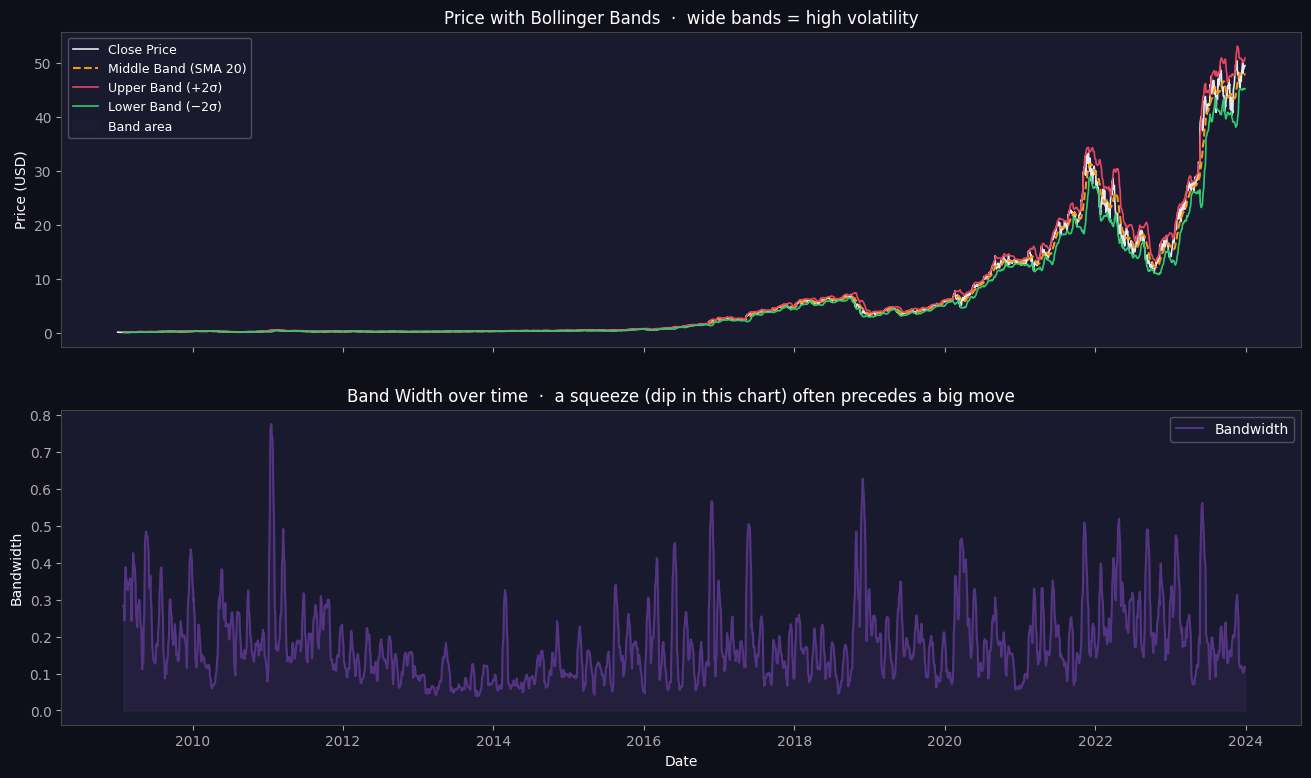

Key insight: When the bandwidth drops to a multi-year low (a "squeeze"), pay attention —
a large price move (up or down) often follows as volatility expands again.


In [ ]:
df = dfs['NVDA']

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# ── Top: price with bands ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df.index, df['Close'],     color='white',   lw=1.2, alpha=0.9, label='Close Price')
ax.plot(df.index, df['bb_middle'], color='#f39c12', lw=1.5, ls='--',  label='Middle Band (SMA 20)')
ax.plot(df.index, df['bb_upper'],  color='#e94560', lw=1.2,           label='Upper Band (+2σ)')
ax.plot(df.index, df['bb_lower'],  color='#2ecc71', lw=1.2,           label='Lower Band (−2σ)')

# Shade the area between the bands
ax.fill_between(df.index, df['bb_upper'], df['bb_lower'],
                alpha=0.07, color='#533483', label='Band area')

ax.set_ylabel('Price (USD)')
ax.set_title('Price with Bollinger Bands  ·  wide bands = high volatility')
ax.legend(framealpha=0.3, fontsize=9)

# ── Bottom: bandwidth (how wide the bands are) ─────────────────────────────────
ax = axes[1]
ax.plot(df.index, df['bb_bandwidth'], color='#533483', lw=1.5, label='Bandwidth')
ax.fill_between(df.index, df['bb_bandwidth'], alpha=0.2, color='#533483')
ax.set_ylabel('Bandwidth'); ax.set_xlabel('Date')
ax.set_title('Band Width over time  ·  a squeeze (dip in this chart) often precedes a big move')
ax.legend(framealpha=0.3)

plt.show()
print('Key insight: When the bandwidth drops to a multi-year low (a "squeeze"), pay attention —')
print('a large price move (up or down) often follows as volatility expands again.')


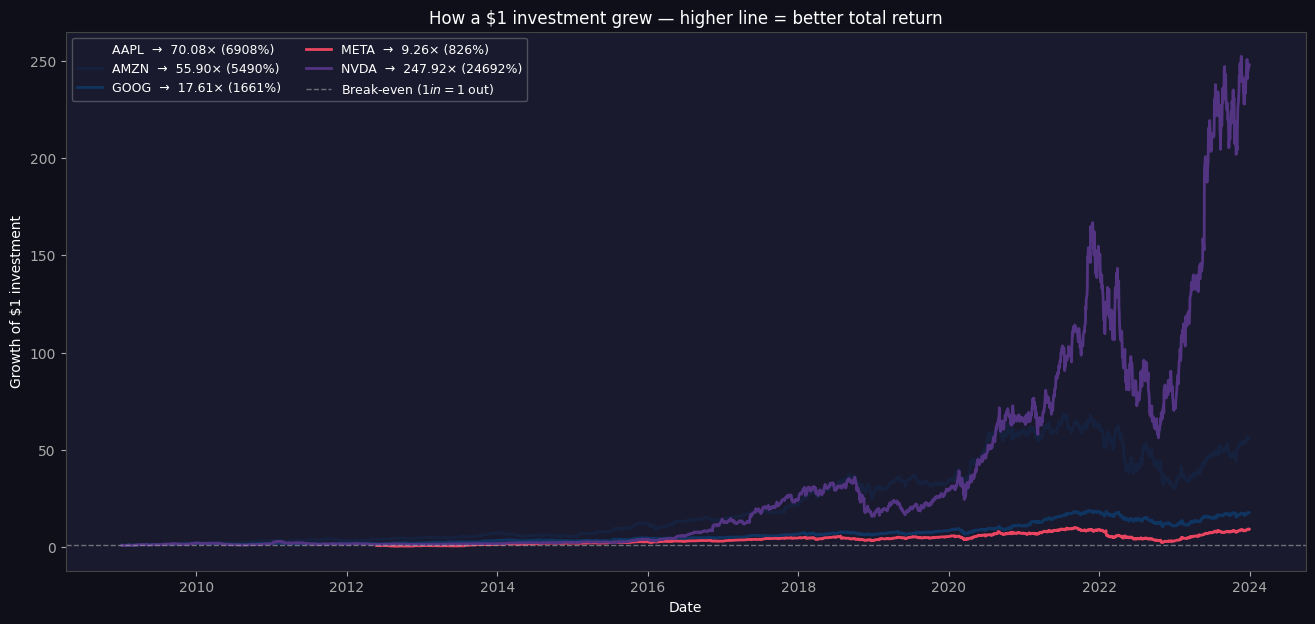


Final cumulative returns:
  AAPL   70.08×  (+6908%)
  AMZN   55.90×  (+5490%)
  GOOG   17.61×  (+1661%)
  META   9.26×  (+826%)
  NVDA   247.92×  (+24692%)


In [ ]:
fig, ax = plt.subplots(figsize=(16, 7))

for i, stock in enumerate(STOCKS):
    cr = dfs[stock]['cumulative_return'].dropna()
    final_return = cr.iloc[-1]
    ax.plot(cr.index, cr,
            color=PALETTE[i], lw=2,
            label=f'{stock}  →  {final_return:.2f}× ({(final_return-1)*100:.0f}%)')

# Mark the break-even line
ax.axhline(1.0, color='#aaa', lw=1.0, ls='--', alpha=0.6, label='Break-even ($1 in = $1 out)')

ax.set_ylabel('Growth of $1 investment'); ax.set_xlabel('Date')
ax.set_title('How a $1 investment grew — higher line = better total return')
ax.legend(framealpha=0.3, fontsize=9, ncol=2)

plt.show()

# Print a summary table
print('\nFinal cumulative returns:')
for stock in STOCKS:
    cr = dfs[stock]['cumulative_return'].dropna().iloc[-1]
    print(f'  {stock:5s}  {cr:.2f}×  ({(cr-1)*100:+.0f}%)')
    

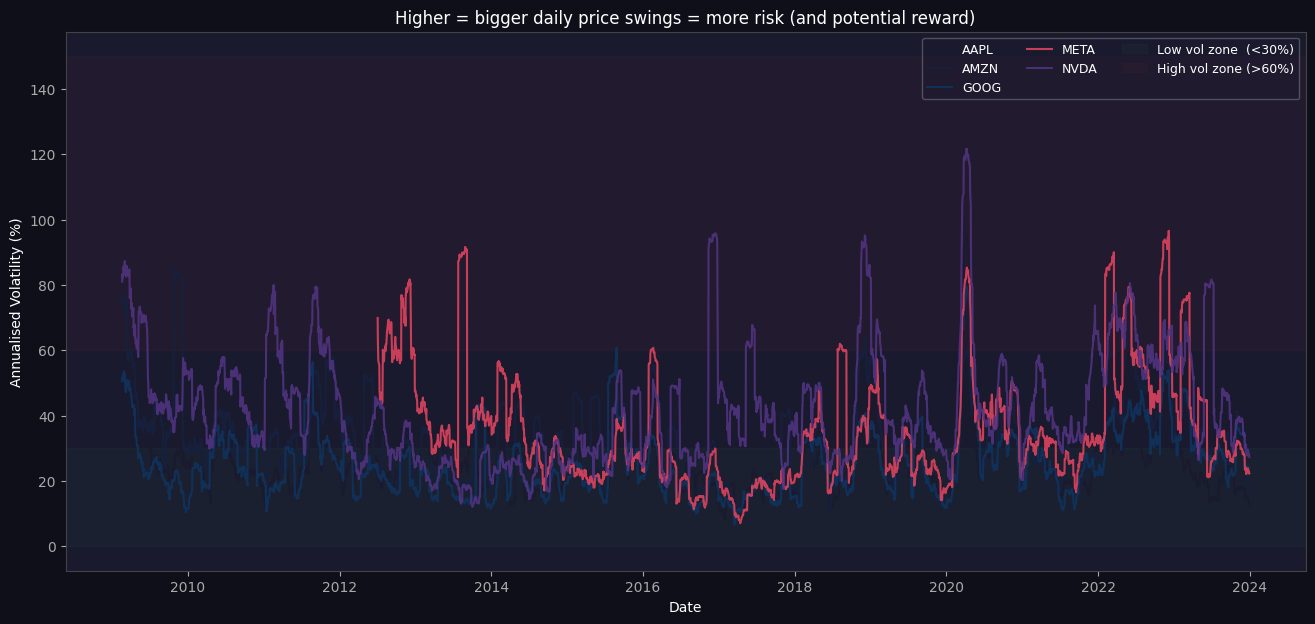

Key insight: Volatility spikes (e.g. early 2020 = COVID crash) affect all stocks.
TSLA and NVDA consistently show higher baseline volatility than MSFT or GOOGL.


In [ ]:
fig, ax = plt.subplots(figsize=(16, 7))

for i, stock in enumerate(STOCKS):
    vol = dfs[stock]['volatility_30d'].dropna()
    ax.plot(vol.index, vol * 100, color=PALETTE[i], lw=1.5, alpha=0.85, label=stock)

# Draw reference zones
ax.axhspan(0,  30, alpha=0.04, color='#2ecc71', label='Low vol zone  (<30%)')
ax.axhspan(60, 150, alpha=0.04, color='#e94560', label='High vol zone (>60%)')

ax.set_ylabel('Annualised Volatility (%)')
ax.set_xlabel('Date')
ax.set_title('Higher = bigger daily price swings = more risk (and potential reward)')
ax.legend(framealpha=0.3, fontsize=9, ncol=3)

plt.show()
print('Key insight: Volatility spikes (e.g. early 2020 = COVID crash) affect all stocks.')
print('TSLA and NVDA consistently show higher baseline volatility than MSFT or GOOGL.')


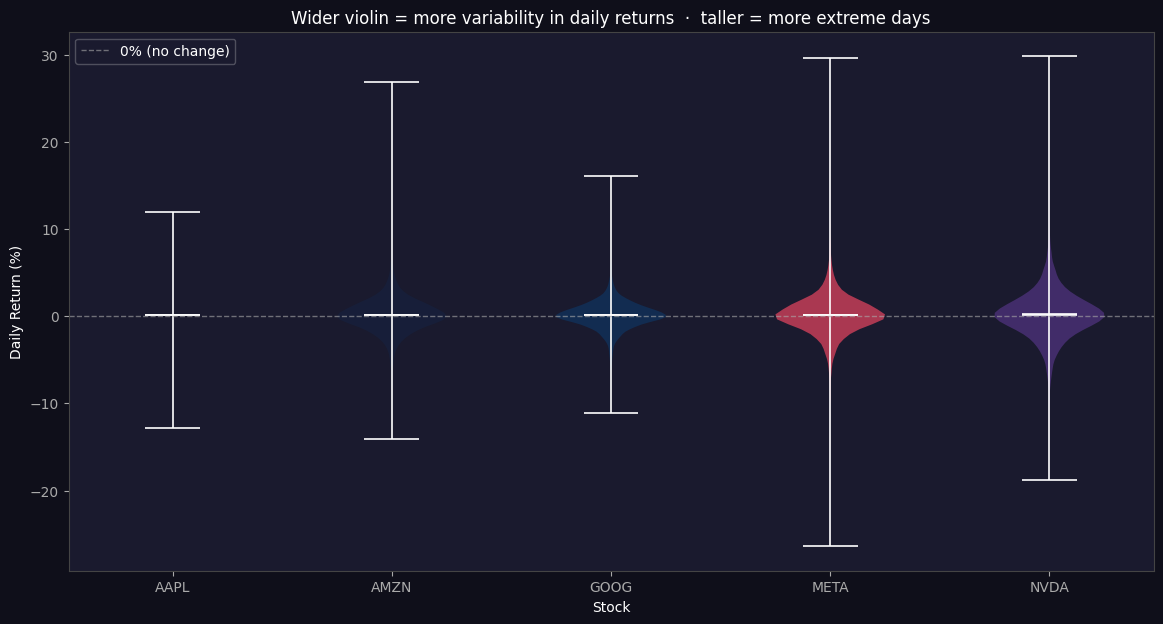


Daily Return Summary:
Stock       Mean   Std Dev       Min       Max
--------------------------------------------------
AAPL      +0.13%     1.80%   -12.86%   +11.98%
AMZN      +0.13%     2.18%   -14.05%   +26.80%
GOOG      +0.09%     1.73%   -11.10%   +16.05%
META      +0.11%     2.53%   -26.39%   +29.61%
NVDA      +0.19%     2.89%   -18.76%   +29.81%


In [16]:
fig, ax = plt.subplots(figsize=(14, 7))

# Collect return data for each stock
return_data = [
    dfs[s]['daily_return'].dropna().values * 100   # convert to %
    for s in STOCKS
]

# Violin plot — wide violin = many days with those return values
parts = ax.violinplot(
    return_data,
    positions=range(len(STOCKS)),
    showmeans=True,
    showmedians=True,
)

# Colour each violin differently
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE[i])
    pc.set_alpha(0.7)
for part in ['cmeans', 'cmedians', 'cbars', 'cmins', 'cmaxes']:
    parts[part].set_color('white')
    parts[part].set_linewidth(1.2)

ax.set_xticks(range(len(STOCKS)))
ax.set_xticklabels(STOCKS)
ax.axhline(0, color='#aaa', lw=1.0, ls='--', alpha=0.6, label='0% (no change)')
ax.set_ylabel('Daily Return (%)')
ax.set_xlabel('Stock')
ax.set_title('Wider violin = more variability in daily returns  ·  taller = more extreme days')
ax.legend(framealpha=0.3)

plt.show()

# Print summary stats for each stock
print('\nDaily Return Summary:')
print(f'{"Stock":6s}  {"Mean":>8s}  {"Std Dev":>8s}  {"Min":>8s}  {"Max":>8s}')
print('-' * 50)
for stock in STOCKS:
    r = dfs[stock]['daily_return'].dropna() * 100
    print(f'{stock:6s}  {r.mean():+7.2f}%  {r.std():7.2f}%  {r.min():+7.2f}%  {r.max():+7.2f}%')